<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml11_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble Learning(앙상블 학습)

*   앙상블(ensemble): ML에서 사용되는 일련의 모델(알고리즘)들.
    *   서로 다른 모델 여러개를 훈련시키는 방법.
    *   한 가지 모델을 서로 다른 훈련 셋으로 훈련시키는 방법.
*   앙상블 학습 방법: 앙상블을 사용한 학습 방법.
    *   투표(voting): 여러 개의 모델들을 같은 훈련 셋으로 학습시킨 후, 각각의 모델에서 예측값들을 투표 방식(최빈값, 평균)으로 예측을 하는 방법.
    *   **Bagging(Bootstrap Aggregating)**: 전체 훈련 셋에서 **중복을 허용**해서 샘플링한 부분집합들로 여러 개의 모델들을 학습시킨 후 예측하는 방법.
        *   병렬 학습이 가능.
        *   **Random Forest**: Bagging을 사용한 Decision Tree들의 앙상블 학습 방법.
    *   Pasting: 전체 훈련 셋에서 중복을 허용하지 않고 샘플링한 부분집합들로 여러 개의 모델들을 학습시킨 후 예측.
    *   **Boosting**: 약한 학습기(weak learner)를 **순차적**으로 연결해서 강한 학습기(strong learner)를 만드는 앙상블 학습 방법.
        *   병렬 학습이 불가능. 훈련 시간이 오래 걸릴 수 있음.
        *   **AdaBoost(Adaptive Boosting)**: 과소적합됐던 훈련 샘플들에 가중치를 높여서 그 다음 학습에서 사용하는 boosting 방법.
        *   **Gradient Boosting**: 잔여 오차(residual errors)들을 다음 훈련에서 학습시키는 boosting 방법.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC  # SVM(Support Vector Machine) 알고리즘을 사용한 분류 모델
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# 데이터 셋 준비

2개 특성(x1, x2)과 2개의 클래스(0, 1)을 갖는 가상의 데이터 셋을 만듦.

In [32]:
# x: 특성 배열, y: 타겟 배열
x, y = datasets.make_moons(n_samples=500, noise=0.3, random_state=42)

In [33]:
x.shape  # shape: (n_samples, n_features)

(500, 2)

In [34]:
y.shape

(500,)

In [35]:
pd.Series(y).value_counts()

,count
1,250
0,250


In [36]:
x[:6]

array([[ 0.83103915, -0.25874875],
       [ 1.18506381,  0.92038714],
       [ 1.16402213, -0.45552558],
       [-0.0236556 ,  1.08628844],
       [ 0.48050273,  1.50942444],
       [ 1.31164912, -0.55117606]])

In [37]:
y[:6]

array([1, 0, 1, 0, 0, 1])

특성 x1은 x축 좌표, 특성 x2는 y축 좌표. 클래스(0 vs 1)별로 색깔을 다르게 시각화.

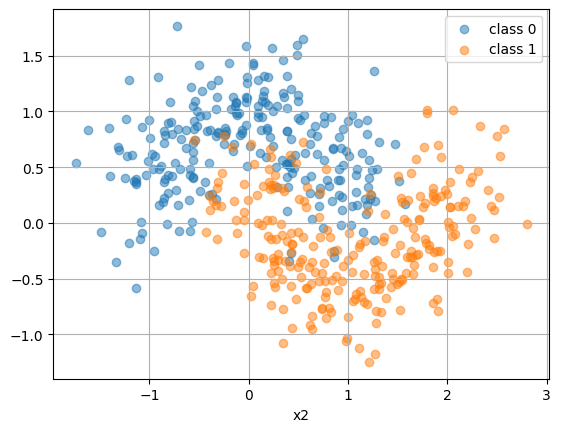

In [38]:
plt.scatter(x=x[y == 0, 0], y=x[y == 0, 1], label='class 0', alpha=0.5)
plt.scatter(x=x[y == 1, 0], y=x[y == 1, 1], label='class 1', alpha=0.5)
plt.legend()
plt.grid()
plt.xlabel('x1')
plt.xlabel('x2')
plt.show()

In [39]:
# 훈련 셋 vs 테스트 셋 나누기
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [40]:
x_train.shape

(400, 2)

# 머신 러닝 모델의 성능 비교

*   5개의 ML 모델 생성
    *   KNN, Decision Tree, Logistic Regression, SGD, SVM 기본 생성자 사용.
        *   SGDClassifier의 파라미터 중에서 loss='log_loss' 사용.
        *   SVC의 파라미터 중에서 probability=True 사용.
*   5개의 모델을 각각 훈련 셋(x_train)으로 학습시킴.
*   5개 모델의 점수(score: 정확도)를 훈련(x_train)/테스트(x_test) 셋에서 계산, 출력.

In [41]:
knn = KNeighborsClassifier()
tree = DecisionTreeClassifier(random_state=42)
logistic = LogisticRegression(random_state=42)
sgd = SGDClassifier(loss='log_loss', random_state=42)
svm = SVC(probability=True, random_state=42)

estimators = [knn, tree, logistic, sgd, svm]

In [43]:
for clf in estimators:
    clf.fit(X=x_train, y=y_train)  # ML 모델 훈련
    train_acc = clf.score(X=x_train, y=y_train)  # 훈련 셋 점수(정확도)
    test_acc = clf.score(X=x_test, y=y_test)  # 테스트 셋 점수(정확도)
    print(f'----- {clf.__class__.__name__} -----')
    print(f'Train({train_acc:.3f}) / Test({test_acc:.3f})')

----- KNeighborsClassifier -----
Train(0.930) / Test(0.930)
----- DecisionTreeClassifier -----
Train(1.000) / Test(0.840)
----- LogisticRegression -----
Train(0.848) / Test(0.810)
----- SGDClassifier -----
Train(0.843) / Test(0.810)
----- SVC -----
Train(0.927) / Test(0.930)


# Voting Ensemble

In [44]:
voting_clf = VotingClassifier(estimators=[('knn', knn),
                                          ('tree', tree),
                                          ('logistic', logistic),
                                          ('sgd', sgd),
                                          ('svm', svm)],
                              voting='soft',
                              n_jobs=-1)

VotingClassifier 생성자 파라미터:

*   `estimators`: 앙상블을 만들기 위한 예측기들의 리스트(list)
    *   리스트의 아이템은 (str, estimator) 형식의 튜플로 설정.
*   `voting`: 투표 방식
    *   `voting='hard'`: 기본값. 단순한 다수결로 예측. 각각의 분류 모델에서 예측 확률을 계산할 필요가 없음.
    *   `voting='soft'`: 각각의 분류 모델에서 계산한 예측 확률을 가중치로 곱한 값을 사용해서 최종 결과를 도출.
    *   soft voting 방식이 일반적으로 성능이 더 좋다고 알려져 있음.


In [45]:
voting_clf.fit(X=x_train, y=y_train)  # 투표 앙상블 모델 훈련

VotingClassifier(estimators=[('knn', KNeighborsClassifier()),
                             ('tree', DecisionTreeClassifier(random_state=42)),
                             ('logistic', LogisticRegression(random_state=42)),
                             ('sgd',
                              SGDClassifier(loss='log_loss', random_state=42)),
                             ('svm', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [46]:
print('train score:', voting_clf.score(X=x_train, y=y_train))
print('test score:', voting_clf.score(X=x_test, y=y_test))

train score: 0.94
test score: 0.92


# Bagging Ensemble

In [47]:
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                n_estimators=50,
                                bootstrap=True,
                                oob_score=True,
                                n_jobs=-1,
                                random_state=42)

BaggingClassifier 생성자 파라미터:

*   `estimator`: 앙상블을 만들 때 사용할 ML 모델(예측기).
*   `n_estimators`: 예측기 개수. 기본값은 10.
*   `max_samples`: 훈련 셋에서 랜덤 샘플링한 부분 집합이 가질 수 있는 최대 샘플 개수(int) 또는 비율(float). 기본값은 1.0.
*   `max_features`: 훈련 셋에서 랜덤 샘플링한 부분 집합이 가질 수 있는 최대 특성 개수(int) 또는 비율(float). 기본값은 1.0.
*   `bootstrap`: 중복 허용 샘플링 사용 여부(bool).
    *   `bootstrap=True`: 중복 허용. bagging(bootstrap aggregating). 기본값.
    *   `bootstrap=False`: 중복 샘플링을 허용하지 않음. pasting.
*   `oob_score`: OOB(Out-of-Bagging) 샘플들을 사용해서 검증 점수를 계산할 지 여부(bool). 기본값은 False.
    *   OOB samples: 중복을 허용해서 샘플링하는 동안 한 번도 샘플링되지 못하고 남아있는 훈련 셋 샘플. 한 번도 학습되지 않은 샘플들.
    *   OOB 샘플들은 검증 셋 역할을 할 수 있음.
    *   OOB 샘플들로 계산된 점수(score: 정확도 또는 결정 계수)는 테스트(검증) 셋에서 계산된 점수와 비슷.

In [48]:
bagging_clf.fit(X=x_train, y=y_train)  # Bagging 분류 모델 훈련

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, oob_score=True, random_state=42)

In [49]:
print('train score:', bagging_clf.score(X=x_train, y=y_train))
print('test score:', bagging_clf.score(X=x_test, y=y_test))

train score: 1.0
test score: 0.89


In [50]:
bagging_clf.oob_score_  # OOB score - 테스트 셋의 정확도와 비슷

0.89

BaggingClassifier
*   estimator: Decision Tree
*   n_estimators: 100
*   cross_validate 함수 사용 - train_score 평균, test_score 평균.

In [51]:
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                n_estimators=100,
                                n_jobs=-1,
                                random_state=42)
cv = cross_validate(estimator=bagging_clf, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [53]:
print('train score:', np.mean(cv['train_score']))
print('validation score:', np.mean(cv['test_score']))

train score: 1.0
validation score: 0.9075


BaggingClassifier
*   estimator: Decision Tree
*   n_estimator: 50
*   max_samples: 100
*   cross_validate 함수 사용 - 훈련 점수, 테스트 점수 평균

In [54]:
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                n_estimators=50,
                                max_samples=100,  # max_samples=0.25
                                n_jobs=-1,
                                random_state=42)
cv = cross_validate(estimator=bagging_clf, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [55]:
print('train score:', np.mean(cv['train_score']))
print('validation score:', np.mean(cv['test_score']))

train score: 0.9418749999999999
validation score: 0.9125


# Random Forest

Random Forest: bagging을 사용한 decision tree들의 ensemble.

*   BaggingClassifier 클래스의 파라미터들을 가지고 있음.
    *   n_estimators, max_samples, ...
*   DecisionTreeClassifier 클래스의 파라미터들을 가지고 있음.
    *   max_depth, min_samples_split, ...
*   교차 검증을 사용해서 decision tree와 bagging ensemble의 하이퍼 파라미터들을 튜닝할 수 있음.


In [56]:
forest = RandomForestClassifier(n_estimators=50, max_samples=100,
                                random_state=42, n_jobs=-1)
cv = cross_validate(estimator=forest, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [57]:
print('train score:', np.mean(cv['train_score']))
print('validation score:', np.mean(cv['test_score']))

train score: 0.9493750000000001
validation score: 0.9274999999999999


## GridSearchCV 사용한 Random Forest 하이퍼 파라미터 튜닝

*   max_depth
*   min_samples_split
*   n_estimators
*   max_samples

In [58]:
# Grid Search에서 사용할 파라미터들의 조합
params = {
    # Decision Tree 하이퍼 파라미터
    'max_depth': np.arange(2, 21),
    'min_samples_split': np.arange(2, 20, 2),
    # Bagging Ensemble 하이퍼 파라미터
    'n_estimators': [50, 100, 200],
    'max_samples': [0.25, 0.5, 0.75, 1.0],
}

In [59]:
grid_cv = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
                       param_grid=params,
                       n_jobs=-1)

In [60]:
grid_cv.fit(X=x_train, y=y_train)

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20]),
                         'max_samples': [0.25, 0.5, 0.75, 1.0],
                         'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                         'n_estimators': [50, 100, 200]})

In [61]:
# 파라미터 그리드의 개수
19 * 9 * 3 * 4

2052

In [62]:
grid_cv.best_params_

{'max_depth': np.int64(6),
 'max_samples': 1.0,
 'min_samples_split': np.int64(2),
 'n_estimators': 200}

In [63]:
grid_cv.best_score_

np.float64(0.925)

# Random Forest를 사용한 red/white wine 분류

In [64]:
wine_df = pd.read_csv('https://bit.ly/wine_csv_data')
feature_names = wine_df.columns[:-1]
x = wine_df[feature_names].values  # 특성 배열
y = wine_df['class'].values  # 타겟 배열

In [65]:
# 훈련 셋 vs 테스트 셋 나누기
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [66]:
# Random Forest 객체 생성
forest = RandomForestClassifier(n_jobs=-1, random_state=42)

In [67]:
# forest.fit(x_train, y_train)
# --> forest.score(x_train, y_train)
# --> forest.score(x_test, y_test)

cv = cross_validate(estimator=forest, X=x_train, y=y_train, n_jobs=-1,
                    return_train_score=True)

In [68]:
print('train score:', np.mean(cv['train_score']))
print('validation score:', np.mean(cv['test_score']))

train score: 0.9981720130385032
validation score: 0.8937817428000298


## Grid Search CV

In [69]:
params = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [2, 4, 10, 20],
    'min_samples_split': [2, 10, 50, 100, 250],
}

In [70]:
grid_cv = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
                       param_grid=params,
                       n_jobs=-1)

In [71]:
grid_cv.fit(X=x_train, y=y_train)

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 4, 10, 20],
                         'min_samples_split': [2, 10, 50, 100, 250],
                         'n_estimators': [10, 50, 100, 200]})

In [72]:
grid_cv.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

In [73]:
grid_cv.best_score_

np.float64(0.8930119567631598)